# Behold the Optical Pumping

In [558]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [559]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename, timeconst):
    ItB = (0.6*10e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

df_25 = add_magnetic_field("linear_zeeman_data/NewFile25kHz.csv",5.000000e-03)
df_50 = add_magnetic_field("linear_zeeman_data/NewFile50kHz.csv",5.000000e-03)
df_75 = add_magnetic_field("linear_zeeman_data/NewFile75kHz.csv",5.000000e-03)
df_100 = add_magnetic_field("linear_zeeman_data/NewFile100kHz.csv",5.000000e-03)
df_125 = add_magnetic_field("linear_zeeman_data/NewFile125kHz.csv",5.000000e-03)
df_150 = add_magnetic_field("linear_zeeman_data/NewFile150kHz.csv",5.000000e-03)
df_175 = add_magnetic_field("linear_zeeman_data/NewFile175kHz.csv",5.000000e-03)
df_195 = add_magnetic_field("linear_zeeman_data/NewFile195kHz.csv",5.000000e-03)

df = [df_25,df_50,df_75,df_100,df_125,df_150,df_175,df_195]

New file: linear_zeeman_data/NewFile25kHz_B.csv
New file: linear_zeeman_data/NewFile50kHz_B.csv
New file: linear_zeeman_data/NewFile75kHz_B.csv
New file: linear_zeeman_data/NewFile100kHz_B.csv
New file: linear_zeeman_data/NewFile125kHz_B.csv
New file: linear_zeeman_data/NewFile150kHz_B.csv
New file: linear_zeeman_data/NewFile175kHz_B.csv
New file: linear_zeeman_data/NewFile195kHz_B.csv


### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

In [560]:
def triple_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    return y0 + L1 + L2 + L3

In [561]:
def quad_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    return y0 + L1 + L2 + L3 + L4

In [562]:
def six_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4, a5, c5, w5, a6, c6, w6):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    L5 = a5 / (1 + ((x - c5) / w5)**2)
    L6 = a6 / (1 + ((x - c6) / w6)**2)
    return y0 + L1 + L2 + L3 + L4 + L5 + L6

In [563]:
def fit_triple_lorentzian(p0, df, result_list):
    x_data, y_data = df["time"], df["CH2norm"]
    popt, pcov = curve_fit(triple_lorentzian, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1: {popt[2]:.4f} ± {perr[2]:.4f}")
    print(f"Lorentzian peak 2: {popt[5]:.4f} ± {perr[5]:.4f}")
    print(f"Lorentzian peak 3: {popt[8]:.4f} ± {perr[8]:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, triple_lorentzian(x_data, *popt), 'r-', 
             linewidth=2, label='Fitted Triple Lorentzian')
    plt.scatter([p0[2], p0[5], p0[8]], [p0[1], p0[4], p0[7]], 
                color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title('Triple Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    result_list.append([popt[5], popt[8]])
    return popt, perr

Lorentzian peak 1: 2.0297 ± 0.0006
Lorentzian peak 2: 2.5016 ± 0.0007
Lorentzian peak 3: 2.3444 ± 0.0014


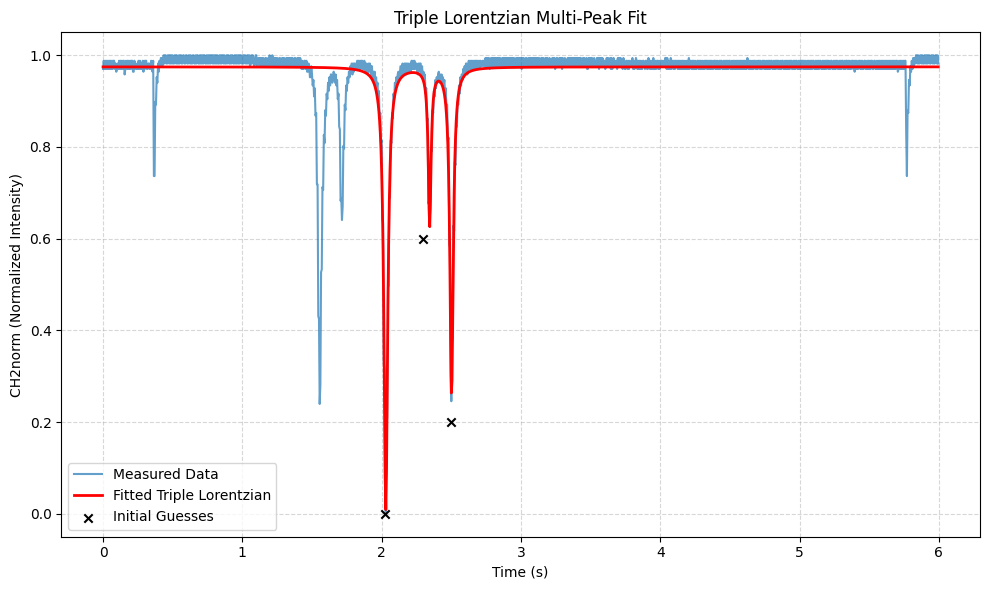

Lorentzian peak 1: 2.1808 ± 0.0012
Lorentzian peak 2: 3.1231 ± 0.0010
Lorentzian peak 3: 2.8085 ± 0.0019


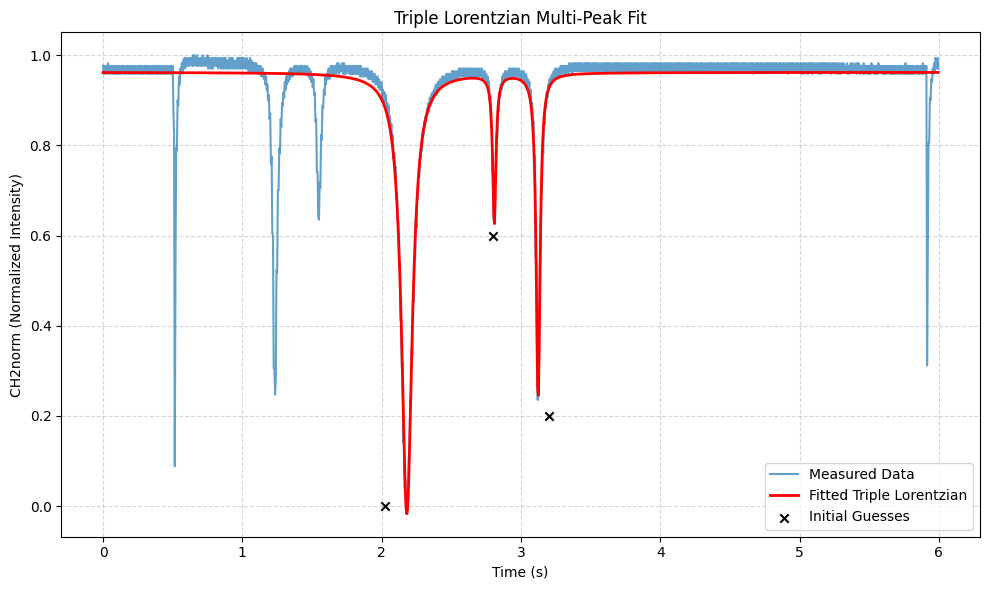

Lorentzian peak 1: 2.1669 ± 0.0015
Lorentzian peak 2: 3.5827 ± 0.0011
Lorentzian peak 3: 3.1096 ± 0.0022


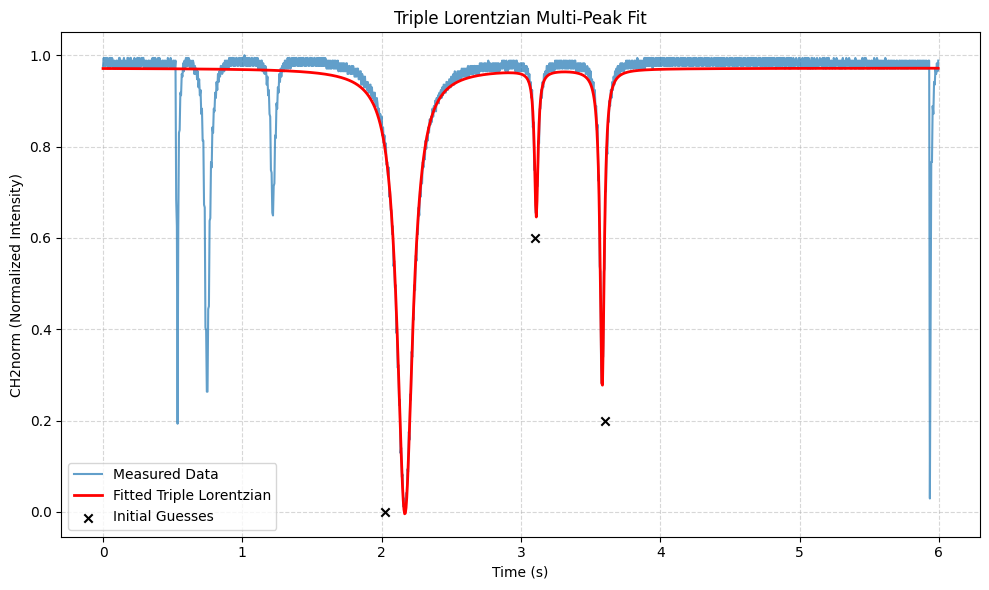

Lorentzian peak 1: 2.1746 ± 0.0011
Lorentzian peak 2: 4.0634 ± 0.0010
Lorentzian peak 3: 3.4342 ± 0.0019


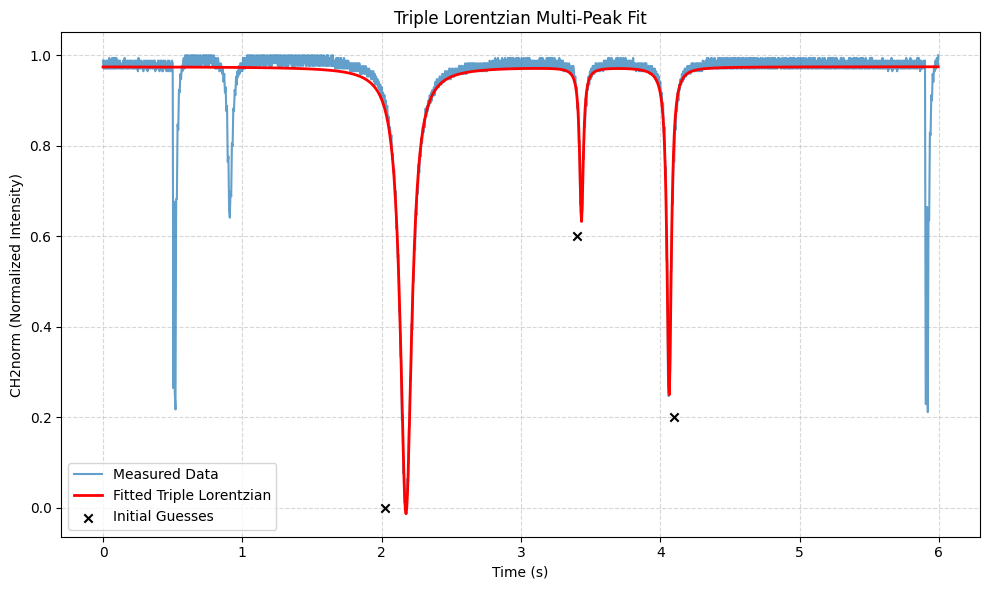

Lorentzian peak 1: 2.1610 ± 0.0014
Lorentzian peak 2: 4.5223 ± 0.0011
Lorentzian peak 3: 3.7356 ± 0.0021


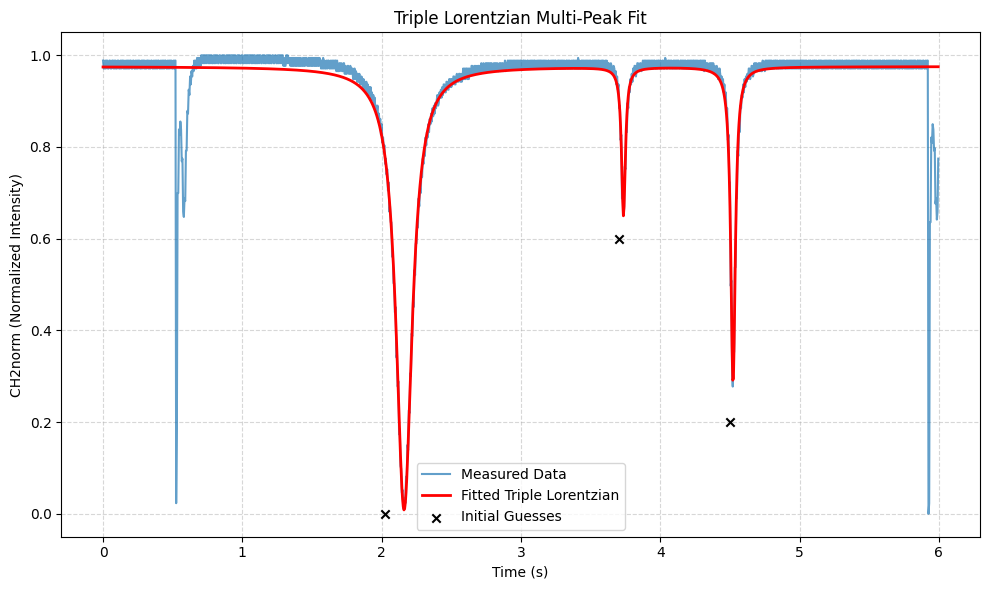

Lorentzian peak 1: 2.1777 ± 0.0008
Lorentzian peak 2: 5.0126 ± 0.0007
Lorentzian peak 3: 4.0688 ± 0.0014


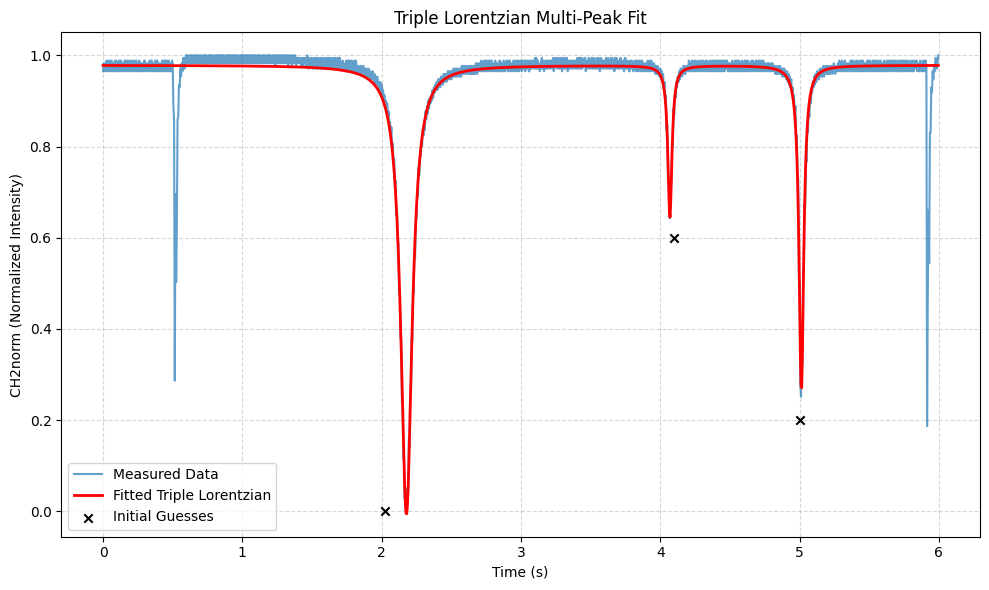

Lorentzian peak 1: 2.1726 ± 0.0010
Lorentzian peak 2: 5.4793 ± 0.0010
Lorentzian peak 3: 4.3788 ± 0.0020


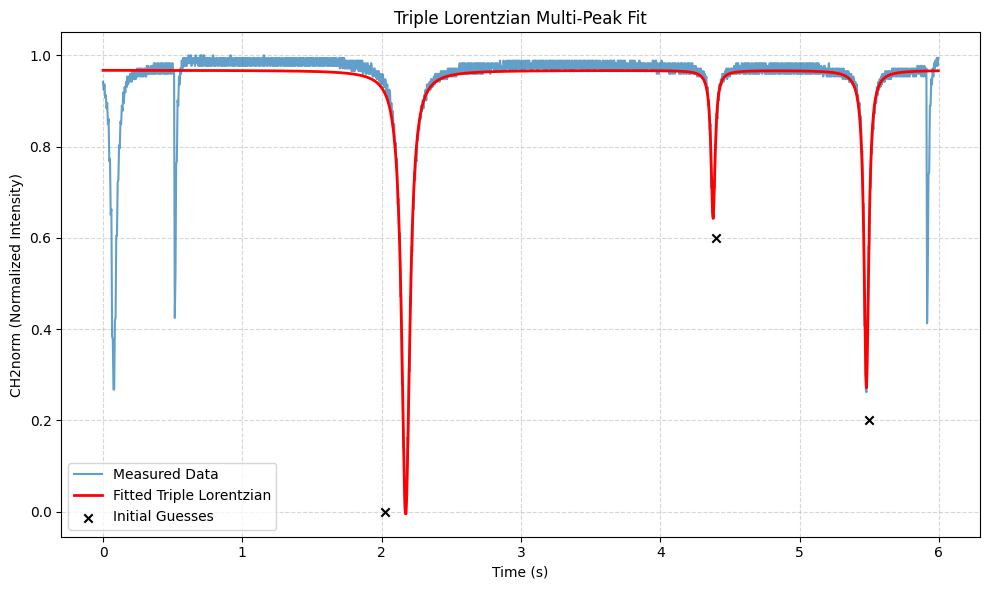

Lorentzian peak 1: 2.0287 ± 0.0006
Lorentzian peak 2: 5.7129 ± 0.0009
Lorentzian peak 3: 4.4885 ± 0.0018


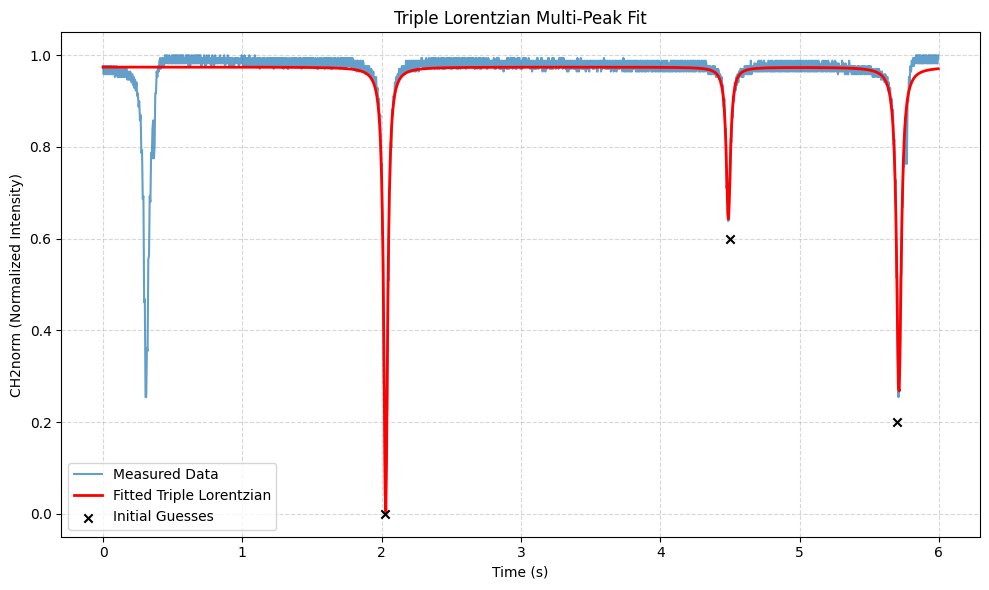

In [564]:
list_of_opt = []
p0guesses = [[1.0,0,2.025,0.018,0.2,2.5,0.023,0.6,2.3,0.022],
             [1.0,0,2.025,0.018,0.2,3.2,0.023,0.6,2.8,0.022],
             [1.0,0,2.025,0.018,0.2,3.6,0.023,0.6,3.1,0.022],
             [1.0,0,2.025,0.018,0.2,4.1,0.023,0.6,3.4,0.022],
             [1.0,0,2.025,0.018,0.2,4.5,0.023,0.6,3.7,0.022],
             [1.0,0,2.025,0.018,0.2,5.0,0.023,0.6,4.1,0.022],
             [1.0,0,2.025,0.018,0.2,5.5,0.023,0.6,4.4,0.022],
             [1.0,0,2.025,0.018,0.2,5.7,0.023,0.6,4.5,0.022]]
i = 0
for df_ in df:
    fit_triple_lorentzian(p0guesses[i],df_,list_of_opt)
    i = i+1

In [565]:
lopt = np.array(list_of_opt)
lopt = lopt.T
lopt = lopt.tolist()
lopt.append([25000,50000,75000,100000,125000,150000,175000,195000])
# lopt = np.array(lopt)
lopt

[[2.5016470058534837,
  3.123095104849237,
  3.5827341651825466,
  4.063414287398456,
  4.522294036233055,
  5.0126427201271015,
  5.479346533224994,
  5.712891942174892],
 [2.3443990707326954,
  2.8084798351956595,
  3.1096092971658478,
  3.434244873385711,
  3.735584273355159,
  4.068817978480627,
  4.378771966873504,
  4.488497590181043],
 [25000, 50000, 75000, 100000, 125000, 150000, 175000, 195000]]

In [566]:
# 1. Organize DataFrames into a list for iterative access
dfs = [df_25, df_50, df_75, df_100, df_125, df_150, df_175, df_195]

def get_bfield_window(df, center_time, window_size=0.005):
    mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
    return df.loc[mask, 'Bfield'].mean()

# 2. Process existing lopt rows to generate the new row
# This logic assumes the new row should correspond to the indices in 'dfs'
# using the values from the first row of lopt (lopt[0])
if len(lopt) > 0:
    new_row = [get_bfield_window(df, lopt[0][i]) for i, df in enumerate(dfs)]
    lopt.append(new_row)

if len(lopt) > 0:
    new_row = [get_bfield_window(df, lopt[1][i]) for i, df in enumerate(dfs)]
    lopt.append(new_row)

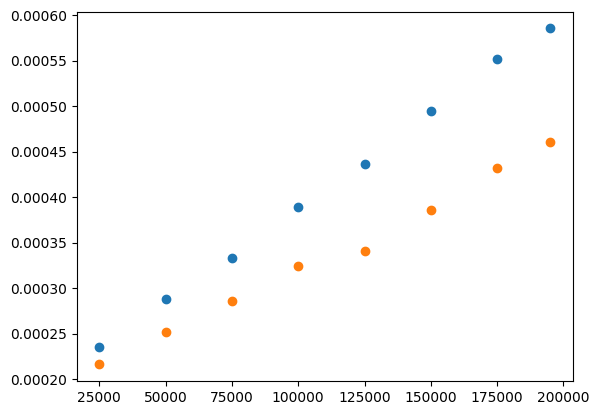

In [567]:
plt.scatter(lopt[2],lopt[3])
plt.scatter(lopt[2],lopt[4])
plt.show()

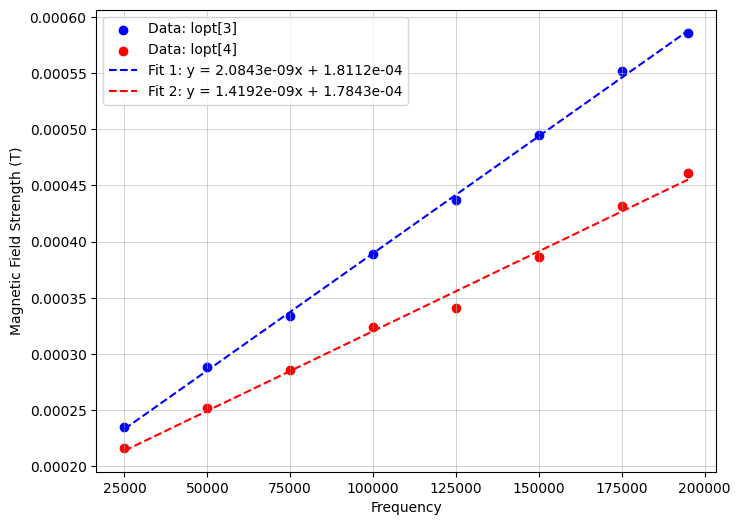

In [568]:
x = np.array(lopt[2])
y1 = np.array(lopt[3])
y2 = np.array(lopt[4])

# Compute linear fits (degree 1 polynomial)
m1, c1 = np.polyfit(x, y1, 1)
m2, c2 = np.polyfit(x, y2, 1)

plt.figure(figsize=(8, 6))

# Plot original scatter data
plt.scatter(x, y1, color='blue', label='Data: lopt[3]')
plt.scatter(x, y2, color='red', label='Data: lopt[4]')

# Plot linear fits, including parameters in the legend
plt.plot(x, m1 * x + c1, color='blue', linestyle='--', 
         label=f'Fit 1: y = {m1:.4e}x + {c1:.4e}')
plt.plot(x, m2 * x + c2, color='red', linestyle='--', 
         label=f'Fit 2: y = {m2:.4e}x + {c2:.4e}')

# Axis labels
plt.xlabel('Frequency')
plt.ylabel('Magnetic Field Strength (T)')

# Faint grid (alpha controls opacity)
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.8)

plt.legend()
plt.show()